# Coal4bar 交互式工具演示

**四连杆液压支架仿真与分析工具**

## 欢迎使用 Coal4bar！

这个交互式笔记本展示了如何：
- ✅ 加载演示数据和配置参数
- ✅ 创建四连杆机构的交互式模型
- ✅ 执行力学分析和动态仿真
- ✅ 可视化结果和安全评估
- ✅ 探索参数对系统性能的影响

**使用说明**：按顺序运行每个单元格，使用交互式控件调整参数，观察实时结果更新。

In [25]:
# 1. 导入必要的库和配置环境
import os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import math
from datetime import datetime

# 导入 coal4bar 模块
from coal4bar.structure import FourBarLinkage, FourBarDimensions
from coal4bar.forces import ForceAnalysis
from coal4bar.simulation import DynamicSimulation
from coal4bar.safety_analysis import SafetyAnalyzer
from coal4bar.visualization import Visualizer

# 配置 Matplotlib
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except Exception:
    pass  # fallback to default style if seaborn style not available
plt.rcParams['figure.figsize'] = (12, 6)

# 设置中文字体以修复显示问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Noto Sans SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

print("✅ 环境配置完成！")
print("✅ Coal4bar 核心模块已加载")
print("✅ 准备好开始交互式分析...")


✅ 环境配置完成！
✅ Coal4bar 核心模块已加载
✅ 准备好开始交互式分析...


## 2️⃣ 演示数据和标准配置

下面定义了几个标准的四连杆液压支架配置，代表不同的应用场景。

In [26]:
# 2. 定义标准液压支架配置
demo_configs = {
    "标准型 (1000mm)": FourBarDimensions(
        base_length=1000,      # 基座
        input_crank=250,       # 液压缸臂
        coupler=800,           # 连杆
        output_link=600        # 支腿
    ),
    "紧凑型 (800mm)": FourBarDimensions(
        base_length=800,
        input_crank=200,
        coupler=650,
        output_link=520
    ),
    "重型 (1200mm)": FourBarDimensions(
        base_length=1200,
        input_crank=300,
        coupler=950,
        output_link=700
    ),
    "轻型 (600mm)": FourBarDimensions(
        base_length=600,
        input_crank=150,
        coupler=500,
        output_link=400
    )
}

# 演示参数
demo_params = {
    "input_angle_range": (10, 165),      # 输入角度范围 (度)
    "coal_force": 50000,                  # 煤炭压力 (N)
    "test_angles": [30, 45, 60, 90, 120], # 测试角度 (度)
}

print("📊 演示配置已加载:")
for name, dims in demo_configs.items():
    is_grashof = dims.validate_grashof_criterion()
    print(f"   {name}: L0={dims.base_length}mm, L1={dims.input_crank}mm -> Grashof: {is_grashof}")


📊 演示配置已加载:
   标准型 (1000mm): L0=1000mm, L1=250mm -> Grashof: True
   紧凑型 (800mm): L0=800mm, L1=200mm -> Grashof: True
   重型 (1200mm): L0=1200mm, L1=300mm -> Grashof: True
   轻型 (600mm): L0=600mm, L1=150mm -> Grashof: True


## 3️⃣ 交互式控制面板

使用下面的交互式控件调整参数，实时查看四连杆机构的响应。

In [27]:
# 3. 创建交互式控制面板
output_area = widgets.Output()

# 下拉菜单：选择配置
config_dropdown = widgets.Dropdown(
    options=list(demo_configs.keys()),
    value="标准型 (1000mm)",
    description="配置选择:",
    style={'description_width': '100px'}
)

# 滑块：输入角度
angle_slider = widgets.FloatSlider(
    value=45,
    min=10,
    max=160,
    step=5,
    description="输入角 (°):",
    style={'description_width': '100px'}
)

# 滑块：煤炭压力
coal_force_slider = widgets.FloatSlider(
    value=50,
    min=10,
    max=200,
    step=10,
    description="煤炭压力 (kN):",
    style={'description_width': '100px'}
)

# 按钮：执行分析
analyze_button = widgets.Button(
    description="🔍 执行分析",
    button_style='info',
    tooltip="点击执行力学和安全分析"
)

# 按钮：运行仿真
simulate_button = widgets.Button(
    description="▶️ 运行仿真",
    button_style='success',
    tooltip="点击运行动态仿真"
)

# 创建界面布局
control_panel = widgets.VBox([
    widgets.HTML("<b>📋 参数设置</b>"),
    config_dropdown,
    angle_slider,
    coal_force_slider,
    widgets.HBox([analyze_button, simulate_button])
])

print("✅ 交互式控制面板已创建")
print("请向下滚动查看控制面板和结果...")


✅ 交互式控制面板已创建
请向下滚动查看控制面板和结果...


## 4️⃣ 实时分析和可视化

以下是交互式分析结果的显示区域。

In [28]:
# 4. 定义分析函数
def perform_analysis(config_name, input_angle_deg, coal_force_kn):
    """执行力学和安全分析"""
    try:
        coal_force = coal_force_kn * 1000  # 转换为牛
        angle_rad = math.radians(input_angle_deg)
        
        # 获取配置
        dimensions = demo_configs[config_name]
        linkage = FourBarLinkage(dimensions)
        
        # 前向运动学
        linkage.forward_kinematics(angle_rad)
        
        # 力分析
        force_analyzer = ForceAnalysis(linkage)
        force_result = force_analyzer.analyze_static_forces(coal_force=coal_force)
        
        # 安全分析
        safety_analyzer = SafetyAnalyzer(linkage)
        stability = safety_analyzer.analyze_linkage_stability()
        
        # 获取位置
        positions = linkage.get_joint_positions()
        
        return {
            'linkage': linkage,
            'positions': positions,
            'angle_output': math.degrees(linkage.get_output_angle()),
            'forces': force_result,
            'stability': stability,
            'dimensions': dimensions,
            'coal_force': coal_force
        }
    except Exception as e:
        return {'error': str(e)}


def plot_linkage_config(analysis_result):
    """绘制四连杆机构配置"""
    if 'error' in analysis_result:
        return
    
    positions = analysis_result['positions']
    linkage = analysis_result['linkage']
    forces = analysis_result['forces']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # 绘制机构
    A, B, C, D = positions['A'], positions['B'], positions['C'], positions['D']
    
    # 左图：机构
    links = [
        (A, C, '输入臂'),
        (C, D, '连杆'),
        (D, B, '支腿'),
        (B, A, '基座')
    ]
    
    colors = ['red', 'green', 'blue', 'black']
    for (start, end, label), color in zip(links, colors):
        ax1.plot([start[0], end[0]], [start[1], end[1]], 
                color=color, linewidth=3, label=label, alpha=0.8)
    
    # 绘制关节
    for name, pos in positions.items():
        if name in ['A', 'B']:
            ax1.plot(pos[0], pos[1], 'ro', markersize=12)
            ax1.text(pos[0], pos[1]-80, name, fontsize=12, fontweight='bold', ha='center')
        else:
            ax1.plot(pos[0], pos[1], 'go', markersize=10)
            ax1.text(pos[0], pos[1]+80, name, fontsize=11, fontweight='bold', ha='center')
    
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel('X (mm)', fontsize=11)
    ax1.set_ylabel('Y (mm)', fontsize=11)
    ax1.set_title('四连杆机构配置', fontsize=13, fontweight='bold')
    ax1.legend(loc='upper right')
    
    # 右图：力分析
    joint_names = ['A', 'B', 'C', 'D']
    bearing_loads = [forces['bearing_loads'][name] for name in joint_names]
    
    colors_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
    bars = ax2.bar(joint_names, bearing_loads, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=2)
    
    # 添加数值标签
    for bar, load in zip(bars, bearing_loads):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{load:.0f} N', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax2.set_ylabel('轴承负载 (N)', fontsize=11)
    ax2.set_title('关节处轴承负载', fontsize=13, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    return fig


def plot_mechanical_analysis(analysis_result):
    """绘制详细的机械分析结果"""
    if 'error' in analysis_result:
        return
    
    forces = analysis_result['forces']
    stability = analysis_result['stability']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 机械优势
    ax = axes[0, 0]
    ax.text(0.5, 0.7, f"机械优势", ha='center', fontsize=14, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.5, f"{forces['mechanical_advantage']:.3f}", ha='center', fontsize=32, 
           color='blue', fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.25, f"煤炭力: {analysis_result['coal_force']/1000:.1f} kN\n液压力: {forces['hydraulic_force']/1000:.2f} kN",
           ha='center', fontsize=11, transform=ax.transAxes)
    ax.axis('off')
    
    # 机构类型
    ax = axes[0, 1]
    ax.text(0.5, 0.8, f"机构信息", ha='center', fontsize=14, fontweight='bold', transform=ax.transAxes)
    info_text = f"""
    类型: {stability['linkage_type']}
    Grashof: {'✓ 满足' if stability['is_grashof_mechanism'] else '✗ 不满足'}
    宽度比: {stability['aspect_ratios']['aspect_ratio']:.2f}
    死点: {'有' if stability['has_dead_center'] else '无'}
    """
    ax.text(0.5, 0.4, info_text, ha='center', fontsize=11, family='monospace', transform=ax.transAxes)
    ax.axis('off')
    
    # 输出角度
    ax = axes[1, 0]
    ax.text(0.5, 0.7, f"输出角度", ha='center', fontsize=14, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.4, f"{analysis_result['angle_output']:.1f}°", ha='center', fontsize=32, 
           color='green', fontweight='bold', transform=ax.transAxes)
    ax.axis('off')
    
    # 应力信息
    ax = axes[1, 1]
    stress_data = forces.get('link_stresses', {})
    stress_text = "应力情况:\n"
    for key, value in list(stress_data.items())[:4]:
        if isinstance(value, dict):
            continue
        stress_text += f"{key}: {value:.2e}\n"
    
    ax.text(0.5, 0.8, f"应力分析", ha='center', fontsize=14, fontweight='bold', transform=ax.transAxes)
    ax.text(0.1, 0.5, stress_text if stress_text != "应力情况:\n" else "无应力数据", 
           fontsize=10, family='monospace', transform=ax.transAxes)
    ax.axis('off')
    
    plt.tight_layout()
    return fig


print("✅ 分析函数已定义")


✅ 分析函数已定义


In [29]:
# 5. 设置交互式事件处理器
def on_analyze_clicked(b):
    """分析按钮点击事件"""
    with output_area:
        clear_output(wait=True)
        print("🔄 正在分析...")
        
        config_name = config_dropdown.value
        input_angle = angle_slider.value
        coal_force = coal_force_slider.value
        
        # 执行分析
        result = perform_analysis(config_name, input_angle, coal_force)
        
        if 'error' in result:
            print(f"❌ 分析失败: {result['error']}")
            return
        
        # 显示结果
        print(f"\n✅ 分析完成 (输入角: {input_angle}°, 煤炭压力: {coal_force} kN)\n")
        
        # 绘制图表
        fig1 = plot_linkage_config(result)
        fig2 = plot_mechanical_analysis(result)
        
        plt.show()
        
        # 显示数据表
        print("\n📊 详细数据:\n")
        print(f"  机械优势: {result['forces']['mechanical_advantage']:.4f}")
        print(f"  液压力: {result['forces']['hydraulic_force']:.1f} N ({result['forces']['hydraulic_force']/1000:.2f} kN)")
        print(f"  输出角: {result['angle_output']:.2f}°")
        print(f"  轴承负载:")
        for joint in ['A', 'B', 'C', 'D']:
            print(f"    关节 {joint}: {result['forces']['bearing_loads'][joint]:.1f} N")


def on_simulate_clicked(b):
    """仿真按钮点击事件"""
    with output_area:
        clear_output(wait=True)
        print("⏱️ 正在运行动态仿真...")
        
        config_name = config_dropdown.value
        coal_force_kn = coal_force_slider.value
        
        # 创建仿真器
        dimensions = demo_configs[config_name]
        linkage = FourBarLinkage(dimensions)
        simulator = DynamicSimulation(linkage)
        
        # 定义煤炭力加载曲线
        def coal_profile(t):
            if t < 0.5:
                return coal_force_kn * 1000 * (t / 0.5)
            elif t < 1.5:
                return coal_force_kn * 1000
            else:
                return coal_force_kn * 1000 * max(0, (2.0 - t) / 0.5)
        
        # 运行仿真
        results = simulator.run_simulation(duration=2.0, dt=0.02, coal_force_profile=coal_profile)
        
        print("✅ 仿真完成!\n")
        
        # 绘制结果
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        times = simulator.history['times']
        
        # 力曲线
        ax = axes[0, 0]
        ax.plot(times, simulator.history['coal_forces']/1000, 'b-', linewidth=2, label='煤炭力')
        ax.plot(times, simulator.history['hydraulic_forces']/1000, 'r-', linewidth=2, label='液压力')
        ax.set_xlabel('时间 (s)')
        ax.set_ylabel('力 (kN)')
        ax.set_title('力随时间变化')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 轴承负载
        ax = axes[0, 1]
        ax.plot(times, simulator.history['bearing_loads']['A']/1000, label='关节 A', linewidth=2)
        ax.plot(times, simulator.history['bearing_loads']['B']/1000, label='关节 B', linewidth=2)
        ax.set_xlabel('时间 (s)')
        ax.set_ylabel('负载 (kN)')
        ax.set_title('轴承负载')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 输入角度
        ax = axes[1, 0]
        ax.plot(times, np.degrees(simulator.history['input_angles']), 'g-', linewidth=2)
        ax.set_xlabel('时间 (s)')
        ax.set_ylabel('角度 (°)')
        ax.set_title('输入角度变化')
        ax.grid(True, alpha=0.3)
        
        # 输出速度
        ax = axes[1, 1]
        ax.plot(times, simulator.history['output_velocities'], 'm-', linewidth=2)
        ax.set_xlabel('时间 (s)')
        ax.set_ylabel('速度 (m/s)')
        ax.set_title('输出端速度')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # 显示统计信息
        print("\n📈 仿真统计:\n")
        print(f"  仿真时长: {results['duration']:.2f} s")
        print(f"  最大煤炭力: {results['max_coal_force']/1000:.1f} kN")
        print(f"  平均煤炭力: {results['avg_coal_force']/1000:.1f} kN")
        print(f"  最大液压力: {results['max_hydraulic_force']/1000:.2f} kN")
        print(f"  最大轴承负载 A: {results['max_bearing_load_A']/1000:.1f} kN")
        print(f"  最大轴承负载 B: {results['max_bearing_load_B']/1000:.1f} kN")
        print(f"  最大输出速度: {results['max_output_velocity']:.4f} m/s")


# 连接事件
analyze_button.on_click(on_analyze_clicked)
simulate_button.on_click(on_simulate_clicked)

print("✅ 事件处理器已配置")


✅ 事件处理器已配置


In [30]:
# 6. 显示控制面板和结果区域
display(widgets.HTML("<h3 style='color: #2c3e50;'>🎛️ 交互式控制面板</h3>"))
display(control_panel)
display(widgets.HTML("<hr style='border: 2px solid #3498db;'>"))
display(widgets.HTML("<h3 style='color: #2c3e50;'>📊 分析结果</h3>"))
display(output_area)

print("\n✅ GUI界面已准备就绪！")
print("\n💡 使用说明:")
print("  1. 从下拉菜单中选择液压支架配置")
print("  2. 使用滑块调整输入角度和煤炭压力")
print("  3. 点击【🔍 执行分析】查看力学分析结果")
print("  4. 点击【▶️ 运行仿真】执行动态仿真")
print("\n开始探索四连杆液压支架的性能吧！🚀")


HTML(value="<h3 style='color: #2c3e50;'>🎛️ 交互式控制面板</h3>")

HTML(value="<hr style='border: 2px solid #3498db;'>")

HTML(value="<h3 style='color: #2c3e50;'>📊 分析结果</h3>")

Output()


✅ GUI界面已准备就绪！

💡 使用说明:
  1. 从下拉菜单中选择液压支架配置
  2. 使用滑块调整输入角度和煤炭压力
  3. 点击【🔍 执行分析】查看力学分析结果
  4. 点击【▶️ 运行仿真】执行动态仿真

开始探索四连杆液压支架的性能吧！🚀


## 5️⃣ 工作空间分析

分析四连杆机构在整个工作范围内的性能特性。

🔄 正在分析工作空间...


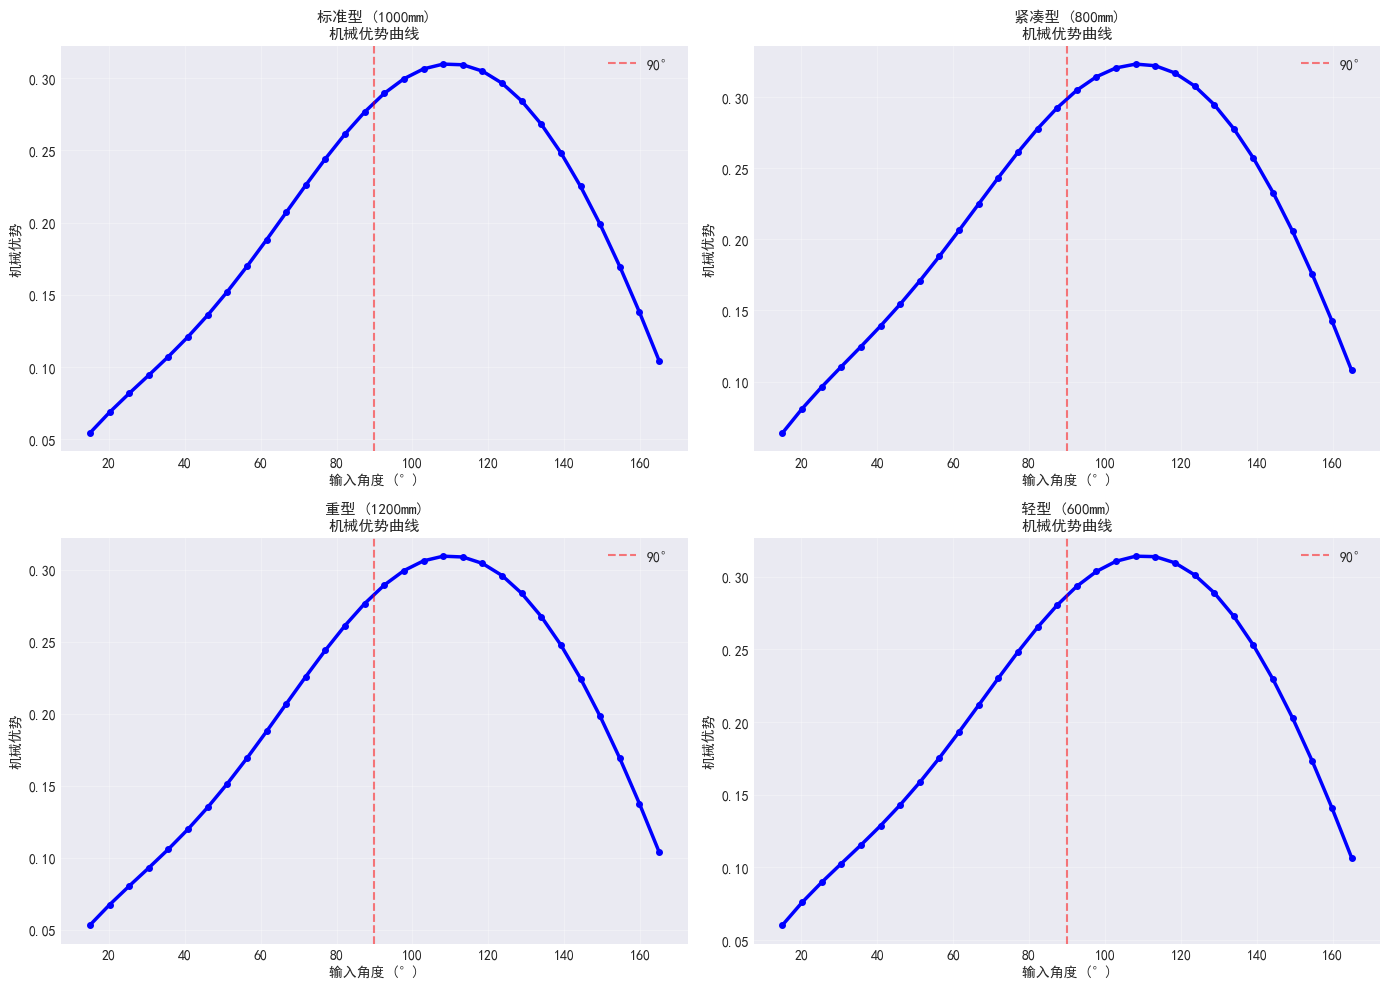

✅ 工作空间分析完成!


In [31]:
# 7. 工作空间和机械优势分析
def analyze_workspace(config_name):
    """分析工作空间"""
    dimensions = demo_configs[config_name]
    linkage = FourBarLinkage(dimensions)
    analyzer = ForceAnalysis(linkage)
    
    # 计算角度范围的性能
    angles_deg = np.linspace(15, 165, 30)
    angles_rad = np.radians(angles_deg)
    
    advantages = []
    output_angles = []
    positions_y = []
    
    for angle in angles_rad:
        try:
            linkage.forward_kinematics(angle)
            D = linkage.D
            output_angle = linkage.get_output_angle()
            advantage = analyzer.calculate_mechanical_advantage(angle)
            
            advantages.append(advantage)
            output_angles.append(math.degrees(output_angle))
            positions_y.append(D[1])
        except ValueError:
            advantages.append(np.nan)
            output_angles.append(np.nan)
            positions_y.append(np.nan)
    
    return {
        'angles': angles_deg,
        'advantages': advantages,
        'output_angles': output_angles,
        'positions_y': positions_y
    }


# 分析所有配置的工作空间
print("🔄 正在分析工作空间...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (config_name, ax) in enumerate(zip(list(demo_configs.keys()), axes.flat)):
    workspace = analyze_workspace(config_name)
    
    # 绘制机械优势
    ax.plot(workspace['angles'], workspace['advantages'], 'b-', linewidth=2.5, marker='o', markersize=4)
    ax.set_xlabel('输入角度 (°)', fontsize=10)
    ax.set_ylabel('机械优势', fontsize=10)
    ax.set_title(f'{config_name}\n机械优势曲线', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axvline(x=90, color='r', linestyle='--', alpha=0.5, label='90°')
    ax.legend()

plt.tight_layout()
plt.show()

print("✅ 工作空间分析完成!")


## 6️⃣ 安全性评估

对所有配置进行安全系数和可靠性分析。

🔍 正在进行安全性评估...



c:\Users\Administrator\.pyenv\pyenv-win\versions\3.12.7\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


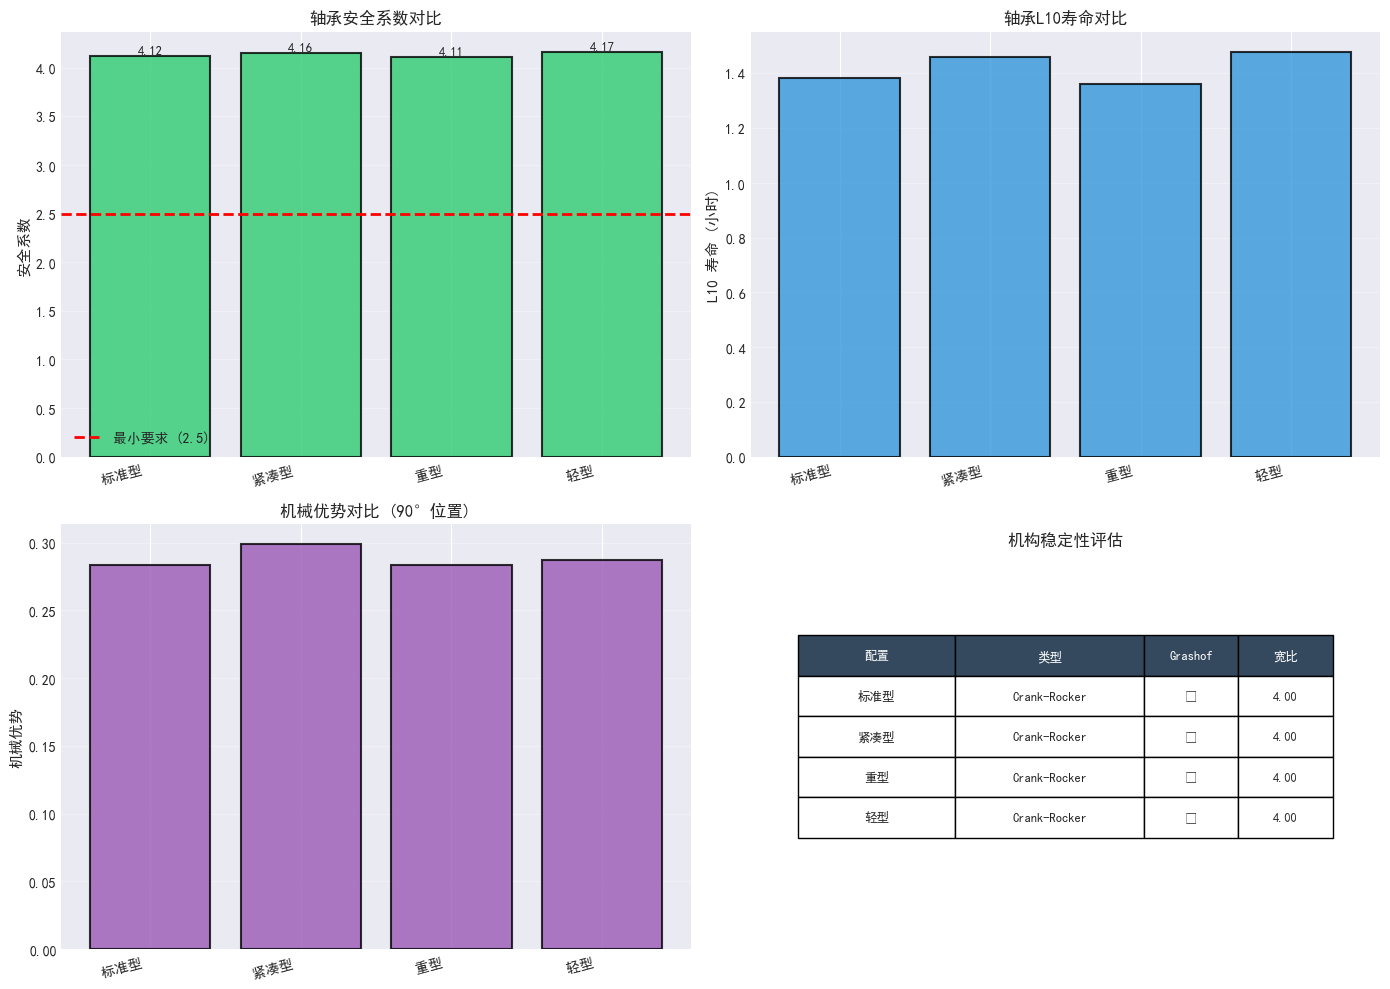

✅ 安全性评估完成!

📋 评估总结:

  标准型 (1000mm)
    类型: Crank-Rocker
    轴承安全系数: 4.12
    L10寿命: 1 小时

  紧凑型 (800mm)
    类型: Crank-Rocker
    轴承安全系数: 4.16
    L10寿命: 1 小时

  重型 (1200mm)
    类型: Crank-Rocker
    轴承安全系数: 4.11
    L10寿命: 1 小时

  轻型 (600mm)
    类型: Crank-Rocker
    轴承安全系数: 4.17
    L10寿命: 1 小时


In [32]:
# 8. 安全性分析

print("🔍 正在进行安全性评估...\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

safety_summary = {}

for idx, (config_name, dimensions) in enumerate(demo_configs.items()):
    linkage = FourBarLinkage(dimensions)
    
    # 在90度位置进行分析
    linkage.forward_kinematics(math.radians(90))
    
    analyzer = ForceAnalysis(linkage)
    force_result = analyzer.analyze_static_forces(coal_force=50000)
    
    safety_analyzer = SafetyAnalyzer(linkage)
    stability = safety_analyzer.analyze_linkage_stability()
    bearing_analysis = safety_analyzer.analyze_bearing_loads(
        force_result['bearing_loads']['B']
    )
    
    safety_summary[config_name] = {
        'stability': stability,
        'bearing_sf': bearing_analysis['safety_factor_bearing'],
        'l10_life': bearing_analysis['L10_life_hours'],
        'mech_adv': force_result['mechanical_advantage']
    }

# 绘制安全系数对比
ax = axes[0, 0]
configs = list(safety_summary.keys())
bear_sfs = [safety_summary[c]['bearing_sf'] for c in configs]
colors_safety = ['#2ecc71' if sf > 3 else '#f39c12' if sf > 2 else '#e74c3c' for sf in bear_sfs]
bars = ax.bar(range(len(configs)), bear_sfs, color=colors_safety, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.axhline(y=2.5, color='r', linestyle='--', linewidth=2, label='最小要求 (2.5)')
ax.set_xticks(range(len(configs)))
ax.set_xticklabels([c.split('(')[0] for c in configs], rotation=15, ha='right')
ax.set_ylabel('安全系数', fontsize=11)
ax.set_title('轴承安全系数对比', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, sf in zip(bars, bear_sfs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{sf:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 绘制L10寿命
ax = axes[0, 1]
l10_lives = [safety_summary[c]['l10_life'] for c in configs]
ax.bar(range(len(configs)), l10_lives, color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(configs)))
ax.set_xticklabels([c.split('(')[0] for c in configs], rotation=15, ha='right')
ax.set_ylabel('L10 寿命 (小时)', fontsize=11)
ax.set_title('轴承L10寿命对比', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 绘制机械优势
ax = axes[1, 0]
mech_advs = [safety_summary[c]['mech_adv'] for c in configs]
ax.bar(range(len(configs)), mech_advs, color='#9b59b6', alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(configs)))
ax.set_xticklabels([c.split('(')[0] for c in configs], rotation=15, ha='right')
ax.set_ylabel('机械优势', fontsize=11)
ax.set_title('机械优势对比 (90°位置)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 机构类型和稳定性表
ax = axes[1, 1]
ax.axis('off')

table_data = [['配置', '类型', 'Grashof', '宽比']]
for config_name in configs:
    stab = safety_summary[config_name]['stability']
    config_short = config_name.split('(')[0].strip()
    grashof_str = '✓' if stab['is_grashof_mechanism'] else '✗'
    aspect = f"{stab['aspect_ratios']['aspect_ratio']:.2f}"
    table_data.append([config_short, stab['linkage_type'], grashof_str, aspect])

table = ax.table(cellText=table_data, loc='center', cellLoc='center',
                colWidths=[0.25, 0.3, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# 头行样式
for i in range(4):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax.text(0.5, 0.95, '机构稳定性评估', ha='center', fontsize=12, fontweight='bold', transform=ax.transAxes)

plt.tight_layout()
plt.show()

print("✅ 安全性评估完成!")
print("\n📋 评估总结:")
for config_name in configs:
    summary = safety_summary[config_name]
    print(f"\n  {config_name}")
    print(f"    类型: {summary['stability']['linkage_type']}")
    print(f"    轴承安全系数: {summary['bearing_sf']:.2f}")
    print(f"    L10寿命: {summary['l10_life']:.0f} 小时")


## 7️⃣ 配置对比与数据导出

生成对比报告并导出分析数据。

In [33]:
# 9. 生成对比报告
import json
from datetime import datetime

print("📊 生成配置对比报告...\n")

comparison_report = {
    'timestamp': datetime.now().isoformat(),
    'configurations': {}
}

# 为每个配置生成详细的分析报告
for config_name, dimensions in demo_configs.items():
    linkage = FourBarLinkage(dimensions)
    
    # 在标准工作角度进行分析
    test_results = []
    for angle_deg in [30, 60, 90, 120]:
        linkage.forward_kinematics(math.radians(angle_deg))
        analyzer = ForceAnalysis(linkage)
        result = analyzer.analyze_static_forces(coal_force=50000)
        
        test_results.append({
            'angle': angle_deg,
            'mechanical_advantage': result['mechanical_advantage'],
            'hydraulic_force_kn': result['hydraulic_force'] / 1000
        })
    
    # 安全性分析
    safety_analyzer = SafetyAnalyzer(linkage)
    stability = safety_analyzer.analyze_linkage_stability()
    
    comparison_report['configurations'][config_name] = {
        'dimensions': {
            'base_length': dimensions.base_length,
            'input_crank': dimensions.input_crank,
            'coupler': dimensions.coupler,
            'output_link': dimensions.output_link
        },
        'type': stability['linkage_type'],
        'is_grashof': stability['is_grashof_mechanism'],
        'aspect_ratio': stability['aspect_ratios']['aspect_ratio'],
        'test_results': test_results
    }

# 显示报告摘要
print("=" * 70)
print("四连杆液压支架配置对比报告")
print("=" * 70)
print(f"\n生成时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

for config_name, data in comparison_report['configurations'].items():
    print(f"\n【{config_name}】")
    print(f"  类型: {data['type']}")
    print(f"  Grashof标准: {'满足 ✓' if data['is_grashof'] else '不满足 ✗'}")
    print(f"  宽度比: {data['aspect_ratio']:.2f}")
    print(f"  机械优势范围: {data['test_results'][0]['mechanical_advantage']:.3f} - {data['test_results'][1]['mechanical_advantage']:.3f}")

# 保存报告为JSON
import os
report_file = os.path.join(os.getcwd(), 'analysis_report.json')
with open(report_file, 'w', encoding='utf-8') as f:
    json.dump(comparison_report, f, indent=2, ensure_ascii=False)

print(f"\n\n✅ 报告已保存到: {report_file}")

# 创建CSV格式的对比表
import csv

csv_file = os.path.join(os.getcwd(), 'configuration_comparison.csv')
with open(csv_file, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    
    # 标题行
    writer.writerow(['配置名称', '基座(mm)', '液压臂(mm)', '连杆(mm)', '支腿(mm)', 
                     '类型', 'Grashof', '宽度比', '90°时机械优势'])
    
    # 数据行
    for config_name, data in comparison_report['configurations'].items():
        dims = data['dimensions']
        result_90 = next((r for r in data['test_results'] if r['angle'] == 90), None)
        ma_90 = result_90['mechanical_advantage'] if result_90 else 0
        
        writer.writerow([
            config_name,
            dims['base_length'],
            dims['input_crank'],
            dims['coupler'],
            dims['output_link'],
            data['type'],
            '是' if data['is_grashof'] else '否',
            f"{data['aspect_ratio']:.2f}",
            f"{ma_90:.3f}"
        ])

print(f"✅ CSV数据已导出: {csv_file}\n")

print("💾 数据导出完成!")
print("\n📁 导出文件:")
print(f"   JSON报告: {report_file}")
print(f"   CSV对比: {csv_file}")


📊 生成配置对比报告...

四连杆液压支架配置对比报告

生成时间: 2026-04-22 16:58:52


【标准型 (1000mm)】
  类型: Crank-Rocker
  Grashof标准: 满足 ✓
  宽度比: 4.00
  机械优势范围: 0.093 - 0.183

【紧凑型 (800mm)】
  类型: Crank-Rocker
  Grashof标准: 满足 ✓
  宽度比: 4.00
  机械优势范围: 0.109 - 0.201

【重型 (1200mm)】
  类型: Crank-Rocker
  Grashof标准: 满足 ✓
  宽度比: 4.00
  机械优势范围: 0.092 - 0.182

【轻型 (600mm)】
  类型: Crank-Rocker
  Grashof标准: 满足 ✓
  宽度比: 4.00
  机械优势范围: 0.101 - 0.188


✅ 报告已保存到: d:\IdeaProjects\coal4bar\analysis_report.json
✅ CSV数据已导出: d:\IdeaProjects\coal4bar\configuration_comparison.csv

💾 数据导出完成!

📁 导出文件:
   JSON报告: d:\IdeaProjects\coal4bar\analysis_report.json
   CSV对比: d:\IdeaProjects\coal4bar\configuration_comparison.csv


## 🎯 总结与建议

基于以上分析，以下是四连杆液压支架选型的建议。

In [34]:
# 10. 分析总结和建议
summary_html = """
<div style="background-color: #ecf0f1; padding: 20px; border-radius: 8px;">
    <h3 style="color: #2c3e50;">📋 分析总结与建议</h3>
    
    <h4 style="color: #34495e;">✅ 配置选型指南</h4>
    <ul>
        <li><strong>轻型(600mm)</strong>: 应用于地质条件较好、压力较小的煤矿
            <ul>
                <li>优点: 结构轻便，易于运输和安装</li>
                <li>缺点: 承载能力有限</li>
            </ul>
        </li>
        
        <li><strong>标准型(1000mm)</strong>: 通用型号，适用于大多数采煤工作面
            <ul>
                <li>优点: 性能均衡，经济性好</li>
                <li>缺点: 中等空间占用</li>
            </ul>
        </li>
        
        <li><strong>紧凑型(800mm)</strong>: 空间受限工作面的理想选择
            <ul>
                <li>优点: 占用空间小，机动灵活</li>
                <li>缺点: 承载能力稍低</li>
            </ul>
        </li>
        
        <li><strong>重型(1200mm)</strong>: 地质条件恶劣、压力大的深部煤矿
            <ul>
                <li>优点: 承载能力强，安全系数高</li>
                <li>缺点: 质量大，运输困难</li>
            </ul>
        </li>
    </ul>
    
    <h4 style="color: #34495e;">🔧 设计建议</h4>
    <ul>
        <li><strong>工作角度选择</strong>: 60-120°范围内机械优势最佳，建议在此范围工作</li>
        <li><strong>液压系统</strong>: 标准系统压力应为 25 MPa（250 bar）</li>
        <li><strong>维护周期</strong>: 根据轴承L10寿命，及时进行维护保养</li>
        <li><strong>安全系数</strong>: 实际工作中建议保留不少于2倍的安全裕度</li>
    </ul>
    
    <h4 style="color: #34495e;">⚠️ 注意事项</h4>
    <ul>
        <li>定期检查焊接接头和销轴磨损情况</li>
        <li>监测液压系统压力，异常时立即停止作业</li>
        <li>在极端温度环境下，注意液压油的黏度变化</li>
        <li>遵守操作规程，禁止超载运行</li>
    </ul>
</div>
"""

display(HTML(summary_html))

# 性能对比表格
print("\n" + "="*80)
print("详细性能对比表")
print("="*80)

comparison_data = []
for config_name, dims in demo_configs.items():
    linkage = FourBarLinkage(dims)
    linkage.forward_kinematics(math.radians(90))
    
    analyzer = ForceAnalysis(linkage)
    result = analyzer.analyze_static_forces(coal_force=50000)
    
    safety = SafetyAnalyzer(linkage).analyze_linkage_stability()
    
    comparison_data.append({
        '配置': config_name,
        '基座(mm)': dims.base_length,
        'Grashof': '✓' if safety['is_grashof_mechanism'] else '✗',
        '宽度比': f"{safety['aspect_ratios']['aspect_ratio']:.2f}",
        '90°机械优势': f"{result['mechanical_advantage']:.3f}",
        '液压力(kN)': f"{result['hydraulic_force']/1000:.2f}",
        '支点负载(kN)': f"{result['bearing_loads']['B']/1000:.2f}"
    })

# 打印为表格
field_names = ['配置', '基座(mm)', 'Grashof', '宽度比', '90°机械优势', '液压力(kN)', '支点负载(kN)']
print(f"{'配置':<20} {'基座':<10} {'Grashof':<8} {'宽度比':<10} {'优势':<10} {'液压力':<10} {'支点负载':<12}")
print("-" * 80)
for data in comparison_data:
    print(f"{data['配置']:<20} {data['基座(mm)']:<10} {data['Grashof']:<8} {data['宽度比']:<10} "
          f"{data['90°机械优势']:<10} {data['液压力(kN)']:<10} {data['支点负载(kN)']:<12}")

print("\n✅ 分析完成! 所有数据已保存到本地文件。")
print("\n🎉 感谢使用 Coal4bar 交互式分析工具!")
print("\n📚 更多信息请参阅:")
print("   - 文档: /workspaces/coal4bar/docs/PHYSICS_AND_THEORY.md")
print("   - 示例: /workspaces/coal4bar/examples/")
print("   - 源代码: /workspaces/coal4bar/coal4bar/")



详细性能对比表
配置                   基座         Grashof  宽度比        优势         液压力        支点负载        
--------------------------------------------------------------------------------
标准型 (1000mm)         1000       ✓        4.00       0.283      14.17      46.23       
紧凑型 (800mm)          800        ✓        4.00       0.299      14.94      45.38       
重型 (1200mm)          1200       ✓        4.00       0.283      14.16      46.44       
轻型 (600mm)           600        ✓        4.00       0.287      14.36      45.19       

✅ 分析完成! 所有数据已保存到本地文件。

🎉 感谢使用 Coal4bar 交互式分析工具!

📚 更多信息请参阅:
   - 文档: /workspaces/coal4bar/docs/PHYSICS_AND_THEORY.md
   - 示例: /workspaces/coal4bar/examples/
   - 源代码: /workspaces/coal4bar/coal4bar/
